# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Customer Shopping Behavior Dataset](https://www.kaggle.com/datasets/rewantbhriguvanshi/customer-shopping-trends-indian?select=customer_shopping_behavior-clean.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

/kaggle/input/datasets/rewantbhriguvanshi/customer-shopping-trends-indian/customer_shopping_behavior-clean.csv
/kaggle/input/datasets/rewantbhriguvanshi/customer-shopping-trends-indian/customer_shopping_behavior.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('customer_shopping_behavior-clean.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,Brand,Color,Size,Quantity,Purchase Amount (₹),Discount (%),Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN500000,CUST001440,2023-07-22,52,Other,Indore,Offline,In-Store Purchase,Clothing,Jeans,Levis,Black,L,1,2215,6,Standard Day,0,N/A (Offline),0,No,Credit Card,5,Not Returned,2,Quarterly
1,TXN500001,CUST002326,2023-01-16,19,Female,Bhubaneswar,Online,Ajio,Clothing,Jacket,Zara,Blue,XS,1,6742,6,Standard Day,0,Express,1,No,Debit Card,4,Returned,3,Quarterly
2,TXN500002,CUST002680,2023-01-24,40,Male,Bangalore,Online,Myntra,Clothing,Saree,Biba,Red,S,1,4672,0,Standard Day,0,Standard,7,Yes,Cash on Delivery,4,Not Returned,13,Monthly
3,TXN500003,CUST001098,2024-09-06,46,Female,Ahmedabad,Offline,In-Store Purchase,Clothing,Jeans,Levis,White,M,1,1539,5,Standard Day,0,N/A (Offline),0,No,UPI,3,Not Returned,1,Rarely
4,TXN500004,CUST003158,2023-10-18,62,Female,Pune,Online,Flipkart,Accessories,Belt,Levis,Red,M,1,2133,3,Standard Day,0,Standard,6,Yes,UPI,3,Not Returned,3,Quarterly


## last Five row

In [4]:
df.tail()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,Brand,Color,Size,Quantity,Purchase Amount (₹),Discount (%),Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
9995,TXN509995,CUST000550,2023-12-21,64,Male,Lucknow,Online,Amazon,Clothing,Shorts,Nike,Blue,S,1,3605,1,Standard Day,0,Standard,7,No,Cash on Delivery,3,Not Returned,17,Fortnightly
9996,TXN509996,CUST003122,2024-05-17,35,Female,Lucknow,Offline,In-Store Purchase,Clothing,Trousers,Roadster,Grey,M,1,1977,1,Standard Day,0,N/A (Offline),0,No,UPI,2,Not Returned,24,Fortnightly
9997,TXN509997,CUST003322,2024-05-06,34,Male,Noida,Online,Amazon,Footwear,Sneakers,Adidas,Grey,8,1,10906,9,Standard Day,40,Standard,6,No,Net Banking,3,Not Returned,8,Monthly
9998,TXN509998,CUST000523,2023-08-22,36,Female,Patna,Online,Meesho,Footwear,Sneakers,Puma,Brown,6,2,10166,6,Standard Day,0,Express,2,Yes,Cash on Delivery,4,Returned,1,Rarely
9999,TXN509999,CUST001343,2024-01-19,33,Female,Mumbai,Online,Flipkart,Footwear,Heels,Bata,Brown,8,1,1706,2,Standard Day,40,Standard,7,No,Cash on Delivery,2,Not Returned,5,Quarterly


## Shape of our dataset

In [5]:
df.shape

(10000, 26)

## List out all columns

In [6]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Purchase Date', 'Age', 'Gender',
       'Location', 'Online/Offline', 'Online Store', 'Category',
       'Item Purchased', 'Brand', 'Color', 'Size', 'Quantity',
       'Purchase Amount (₹)', 'Discount (%)', 'Festival/Sale',
       'Shipping Charge (₹)', 'Delivery Speed', 'Delivery Time (Days)',
       'Subscription Status', 'Payment Method', 'Review Rating',
       'Return Status', 'Previous Purchases', 'Frequency of Purchases'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Transaction ID            object
Customer ID               object
Purchase Date             object
Age                        int64
Gender                    object
Location                  object
Online/Offline            object
Online Store              object
Category                  object
Item Purchased            object
Brand                     object
Color                     object
Size                      object
Quantity                   int64
Purchase Amount (₹)        int64
Discount (%)               int64
Festival/Sale             object
Shipping Charge (₹)        int64
Delivery Speed            object
Delivery Time (Days)       int64
Subscription Status       object
Payment Method            object
Review Rating              int64
Return Status             object
Previous Purchases         int64
Frequency of Purchases    object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Transaction ID          10000 non-null  object
 1   Customer ID             10000 non-null  object
 2   Purchase Date           10000 non-null  object
 3   Age                     10000 non-null  int64 
 4   Gender                  10000 non-null  object
 5   Location                10000 non-null  object
 6   Online/Offline          10000 non-null  object
 7   Online Store            10000 non-null  object
 8   Category                10000 non-null  object
 9   Item Purchased          10000 non-null  object
 10  Brand                   10000 non-null  object
 11  Color                   10000 non-null  object
 12  Size                    10000 non-null  object
 13  Quantity                10000 non-null  int64 
 14  Purchase Amount (₹)     10000 non-null  int64 
 15  Dis

## Check Null Value

In [9]:
df.isnull().sum()

Transaction ID            0
Customer ID               0
Purchase Date             0
Age                       0
Gender                    0
Location                  0
Online/Offline            0
Online Store              0
Category                  0
Item Purchased            0
Brand                     0
Color                     0
Size                      0
Quantity                  0
Purchase Amount (₹)       0
Discount (%)              0
Festival/Sale             0
Shipping Charge (₹)       0
Delivery Speed            0
Delivery Time (Days)      0
Subscription Status       0
Payment Method            0
Review Rating             0
Return Status             0
Previous Purchases        0
Frequency of Purchases    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Age,Quantity,Purchase Amount (₹),Discount (%),Shipping Charge (₹),Delivery Time (Days),Review Rating,Previous Purchases
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,41.095400,1.425900,6467.694500,8.704500,20.472500,2.580500,3.47960,14.678100
std,13.537475,0.725921,8777.617508,7.278893,28.954345,2.466603,0.87319,15.955574
min,18.000000,1.000000,107.000000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,29.000000,1.000000,1659.000000,4.000000,0.000000,0.000000,3.00000,2.000000
50%,41.000000,1.000000,3491.000000,8.000000,0.000000,2.000000,4.00000,9.000000
75%,53.000000,2.000000,7544.250000,12.000000,40.000000,5.000000,4.00000,23.000000
max,64.000000,4.000000,113920.000000,69.000000,99.000000,7.000000,5.00000,85.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

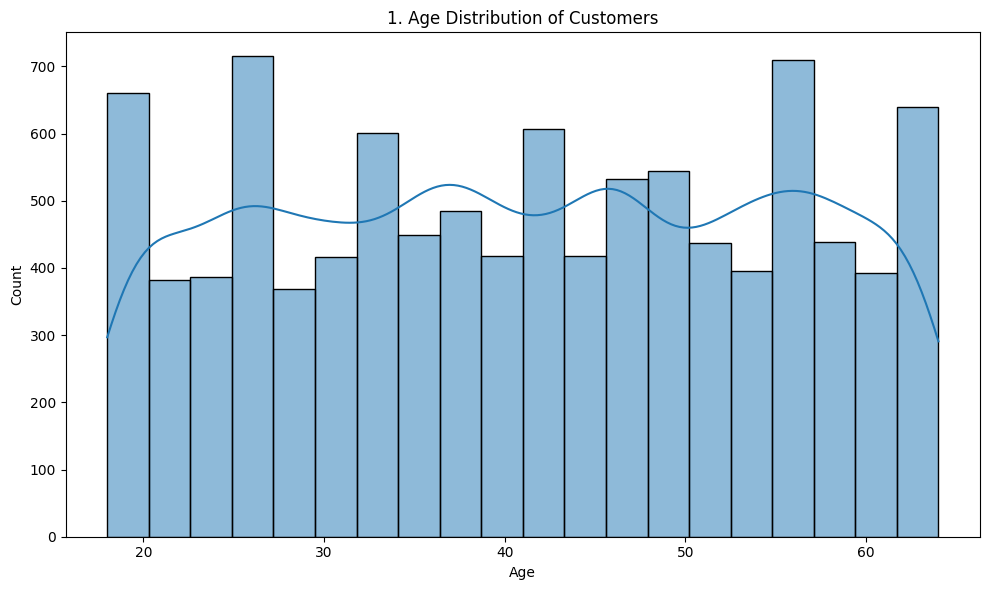

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Customers')
show_fig()
plot_no += 1

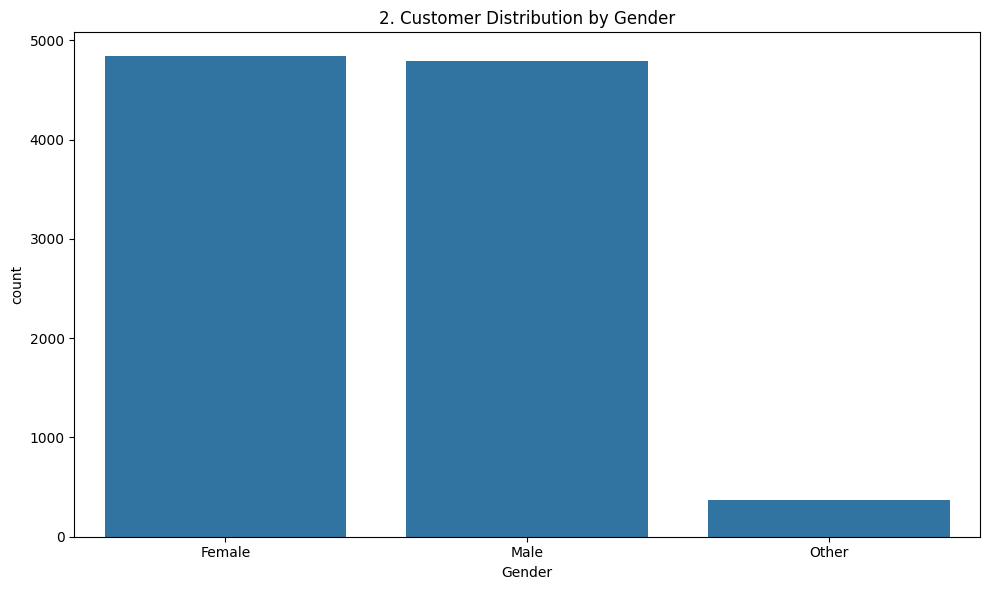

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index)
plt.title(f'{plot_no}. Customer Distribution by Gender')
show_fig()
plot_no += 1

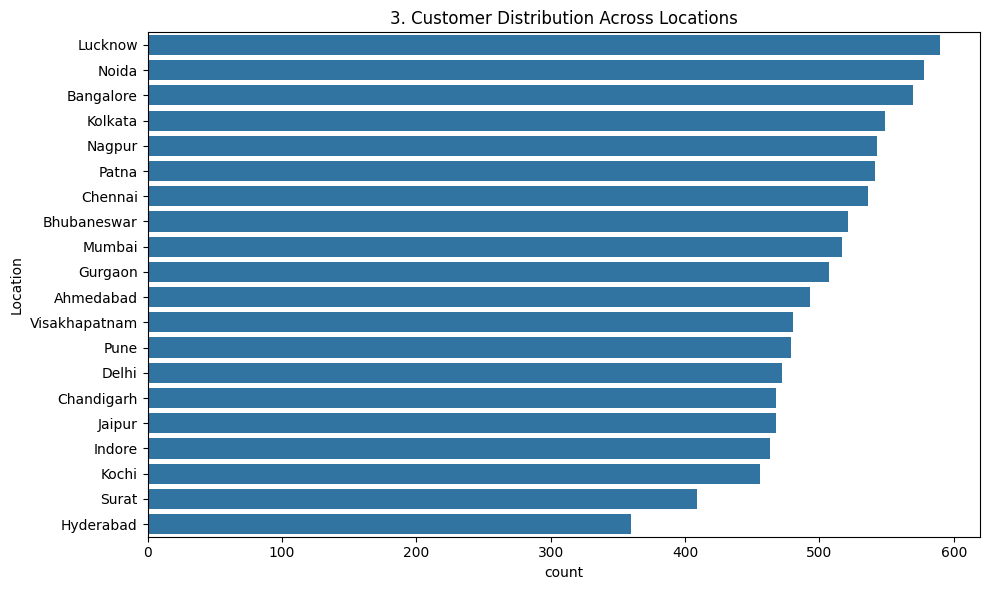

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Location', order=df['Location'].value_counts().index)
plt.title(f'{plot_no}. Customer Distribution Across Locations')
show_fig()
plot_no += 1

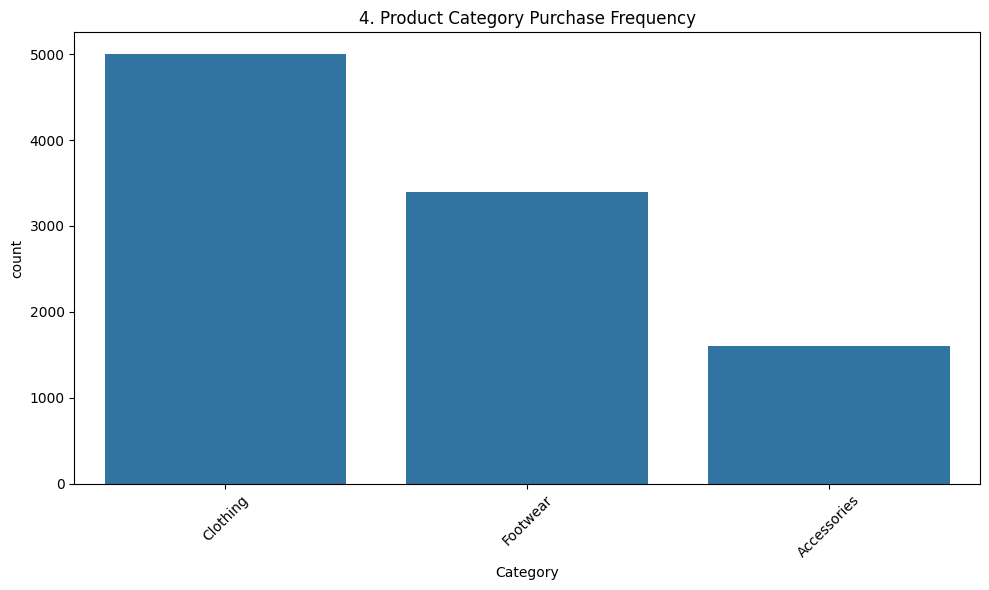

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Product Category Purchase Frequency')
show_fig()
plot_no += 1

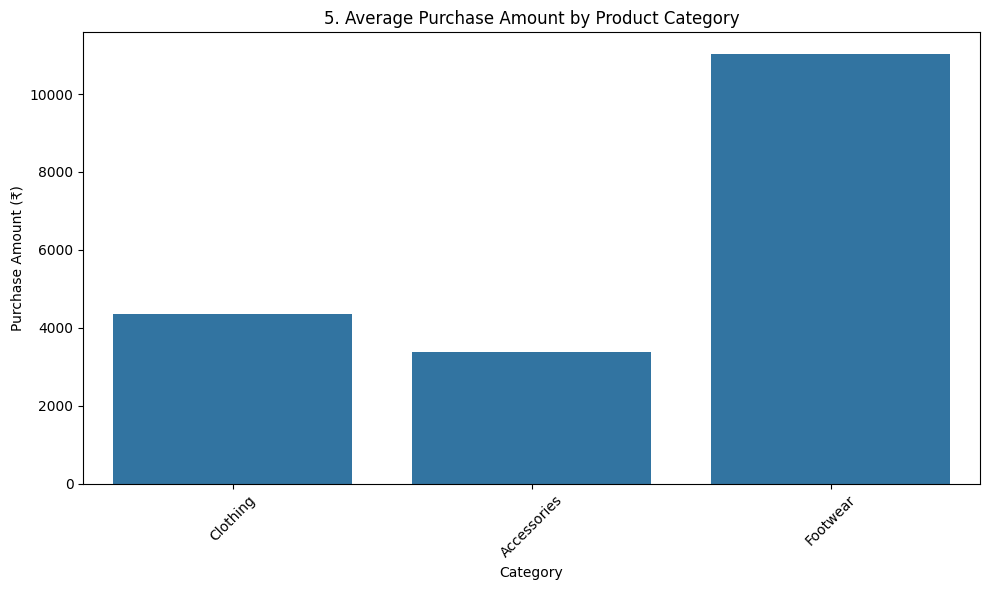

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Category', y='Purchase Amount (₹)', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Purchase Amount by Product Category')
show_fig()
plot_no += 1

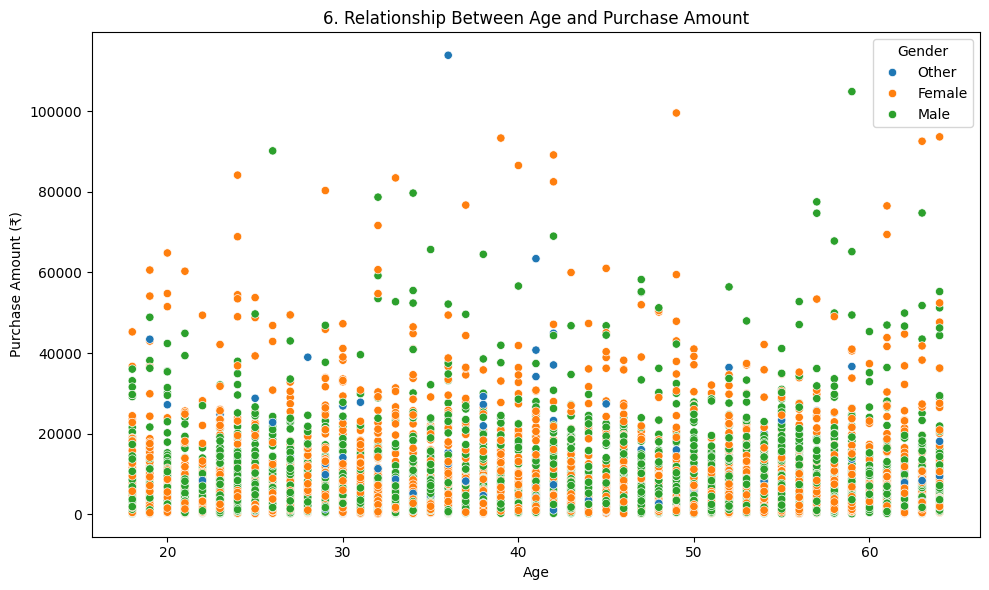

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Purchase Amount (₹)', hue='Gender')
plt.title(f'{plot_no}. Relationship Between Age and Purchase Amount')
show_fig()
plot_no += 1

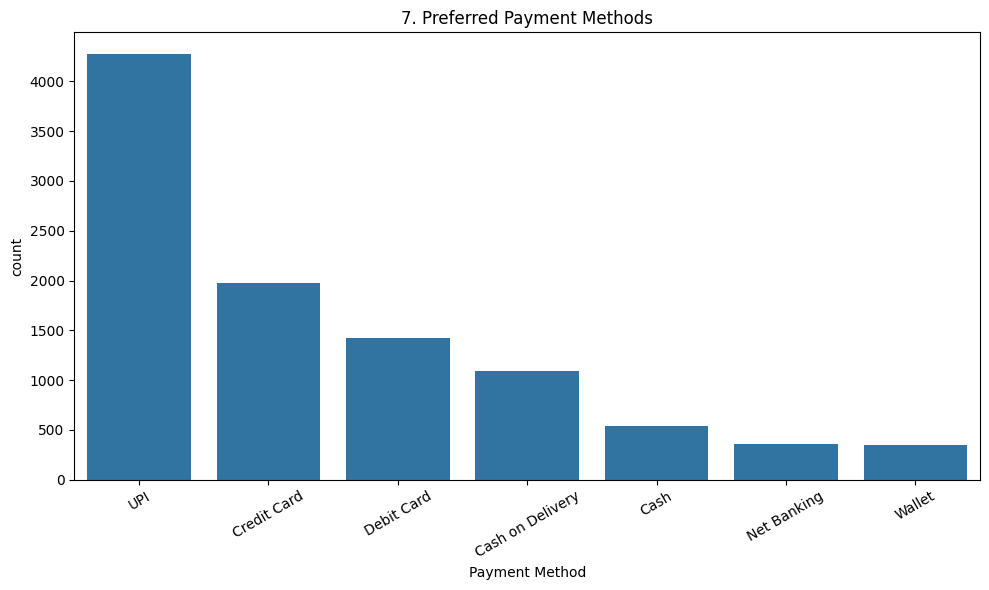

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Payment Method', order=df['Payment Method'].value_counts().index)
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Preferred Payment Methods')
show_fig()
plot_no += 1

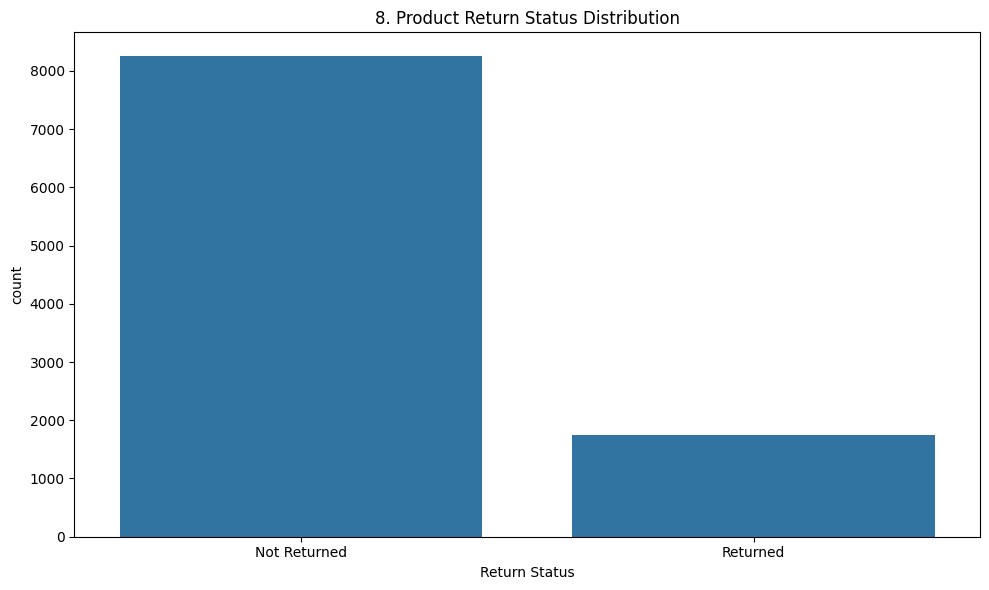

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Return Status')
plt.title(f'{plot_no}. Product Return Status Distribution')
show_fig()
plot_no += 1

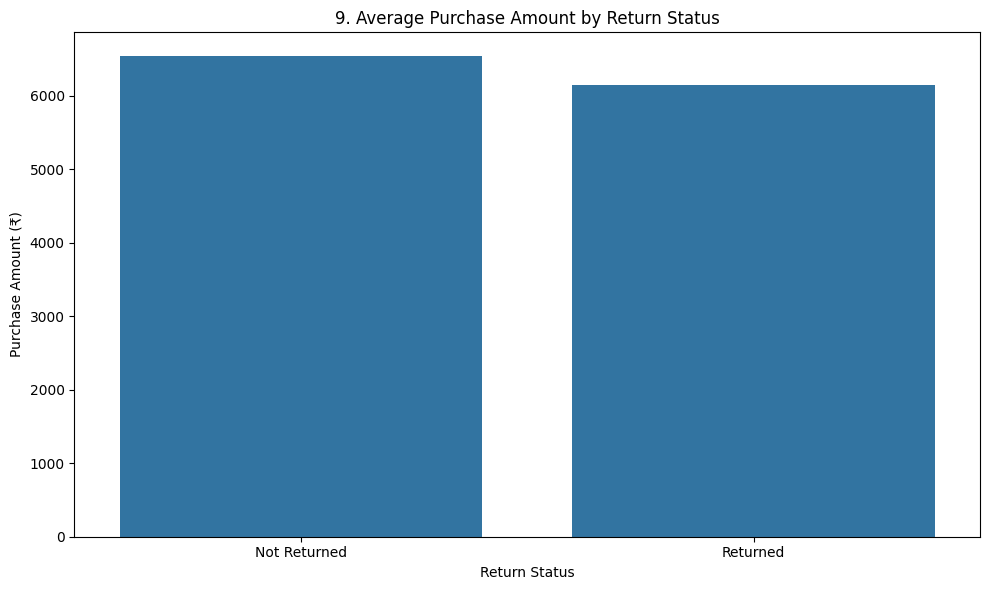

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Return Status', y='Purchase Amount (₹)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Purchase Amount by Return Status')
show_fig()
plot_no += 1

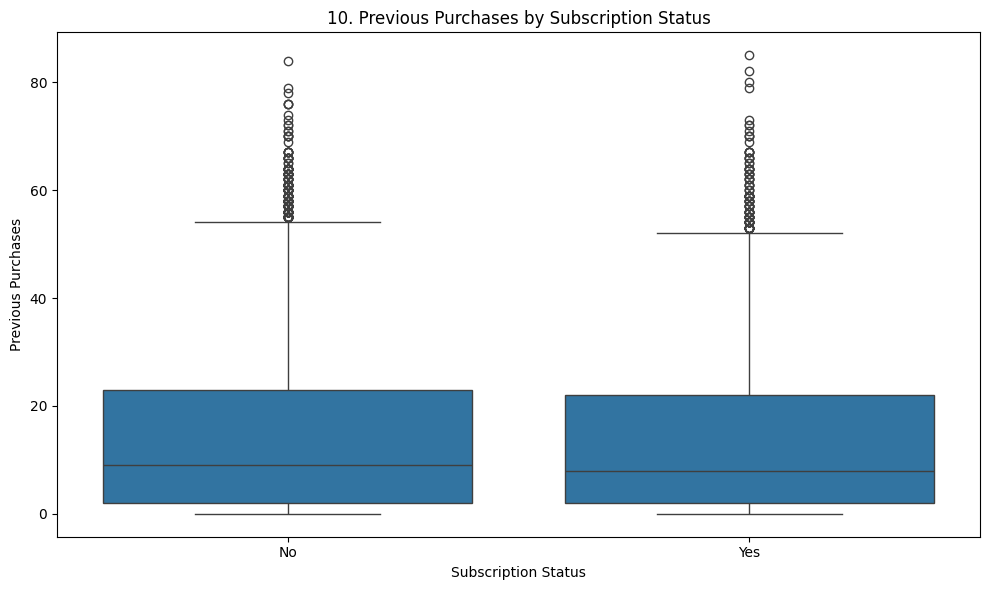

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Subscription Status', y='Previous Purchases')
plt.title(f'{plot_no}. Previous Purchases by Subscription Status')
show_fig()
plot_no += 1

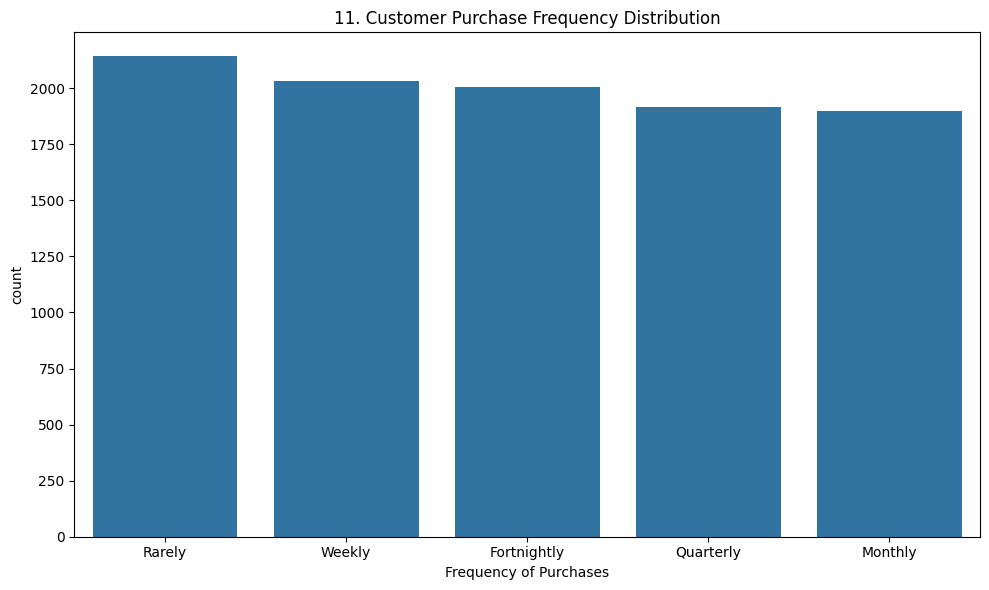

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Frequency of Purchases', order=df['Frequency of Purchases'].value_counts().index)
plt.title(f'{plot_no}. Customer Purchase Frequency Distribution')
show_fig()
plot_no += 1

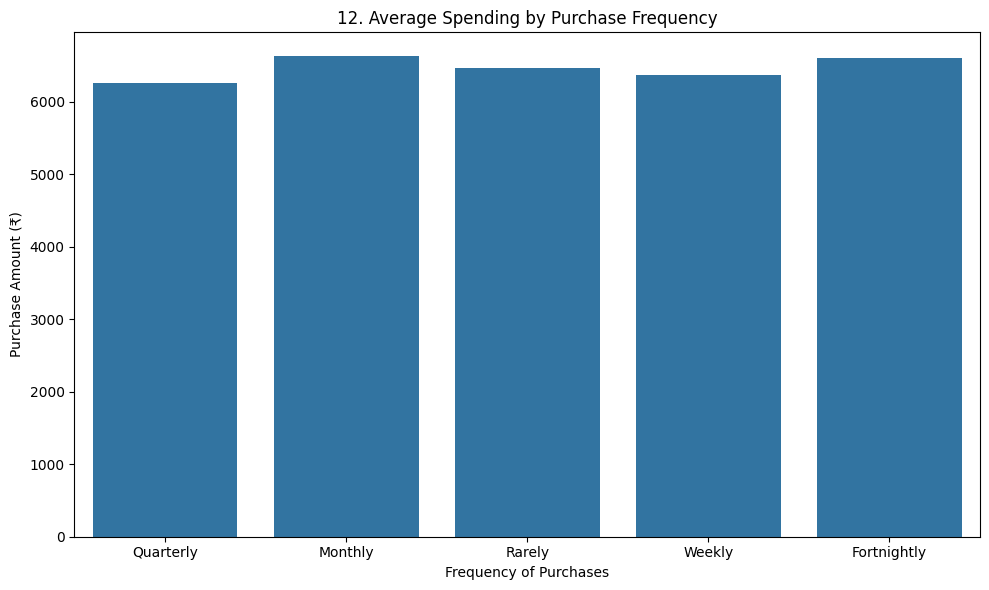

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Frequency of Purchases', y='Purchase Amount (₹)', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Spending by Purchase Frequency')
show_fig()
plot_no += 1

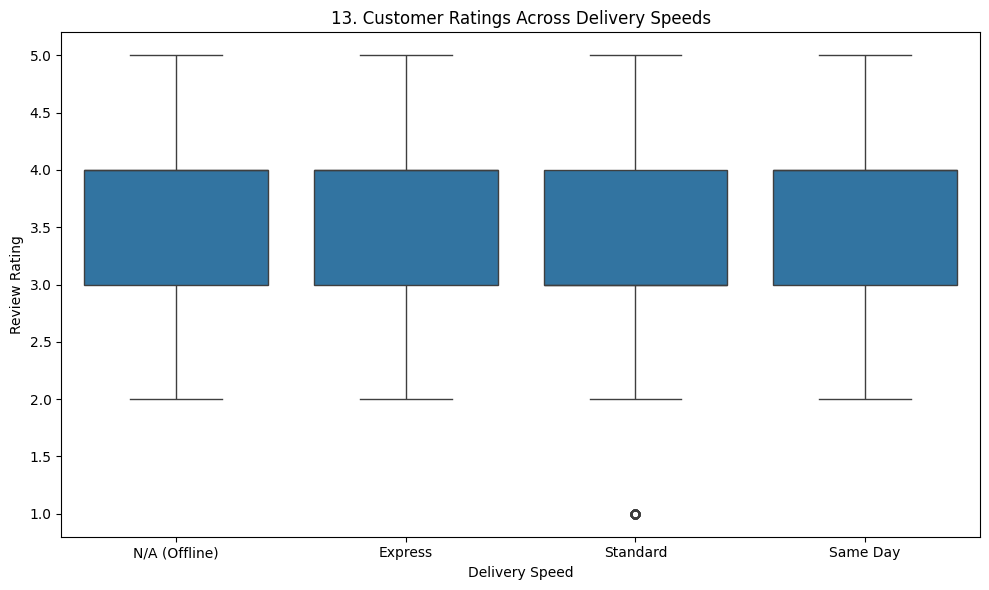

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Delivery Speed', y='Review Rating')
plt.title(f'{plot_no}. Customer Ratings Across Delivery Speeds')
show_fig()
plot_no += 1

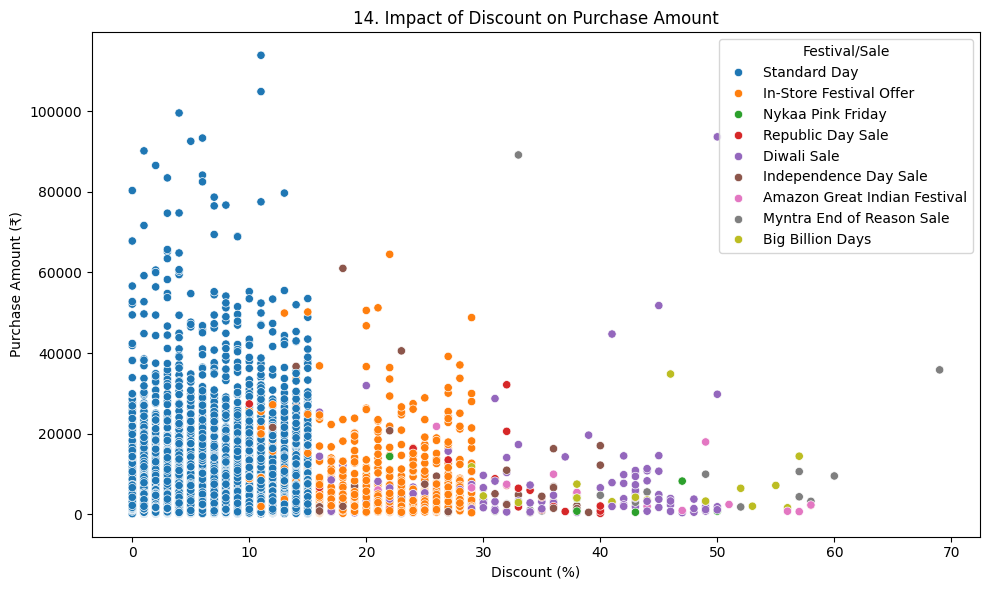

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount (%)', y='Purchase Amount (₹)', hue='Festival/Sale')
plt.title(f'{plot_no}. Impact of Discount on Purchase Amount')
show_fig()
plot_no += 1

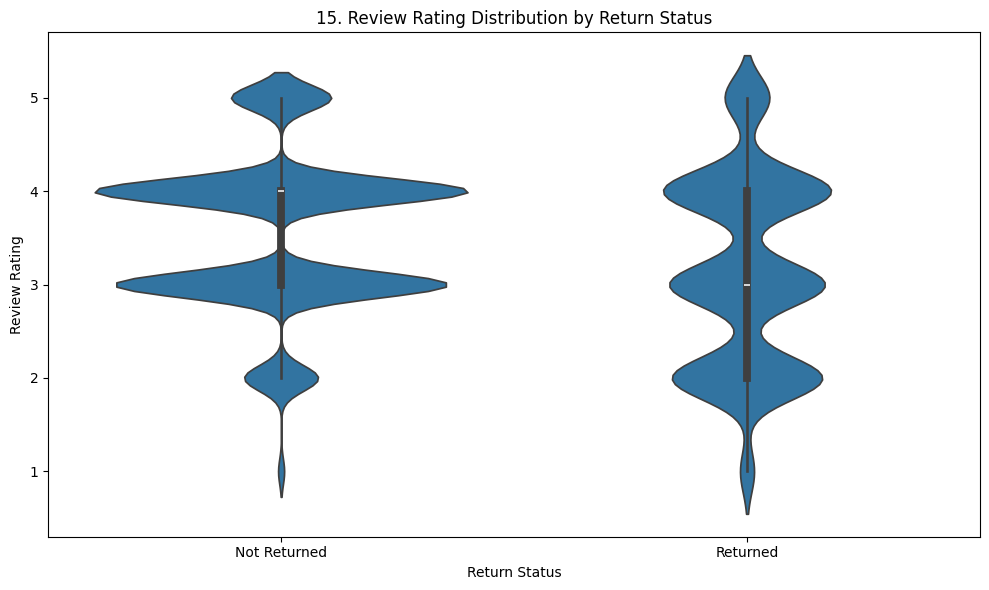

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Return Status', y='Review Rating')
plt.title(f'{plot_no}. Review Rating Distribution by Return Status')
show_fig()
plot_no += 1

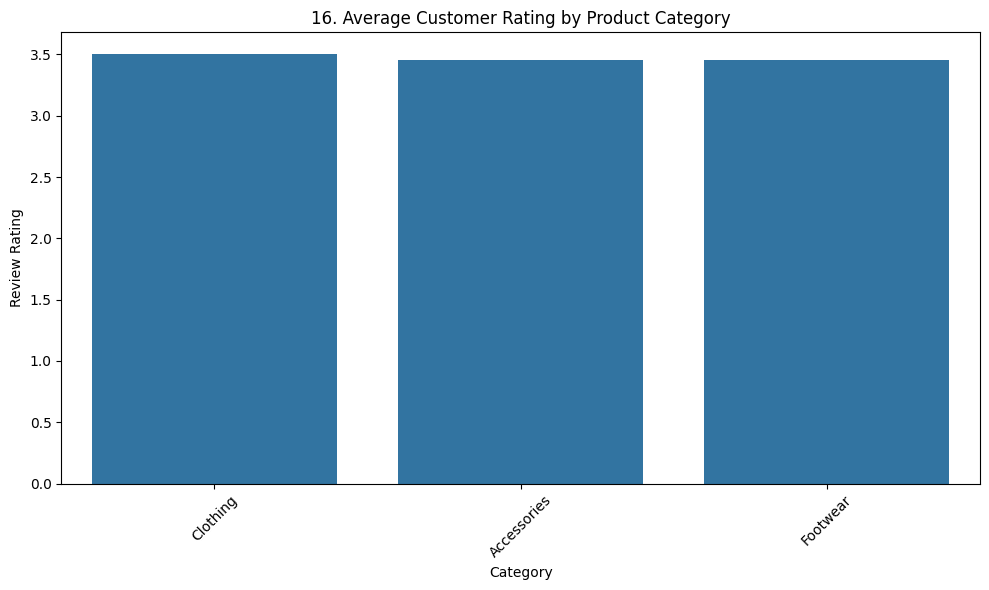

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Category', y='Review Rating', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Customer Rating by Product Category')
show_fig()
plot_no += 1

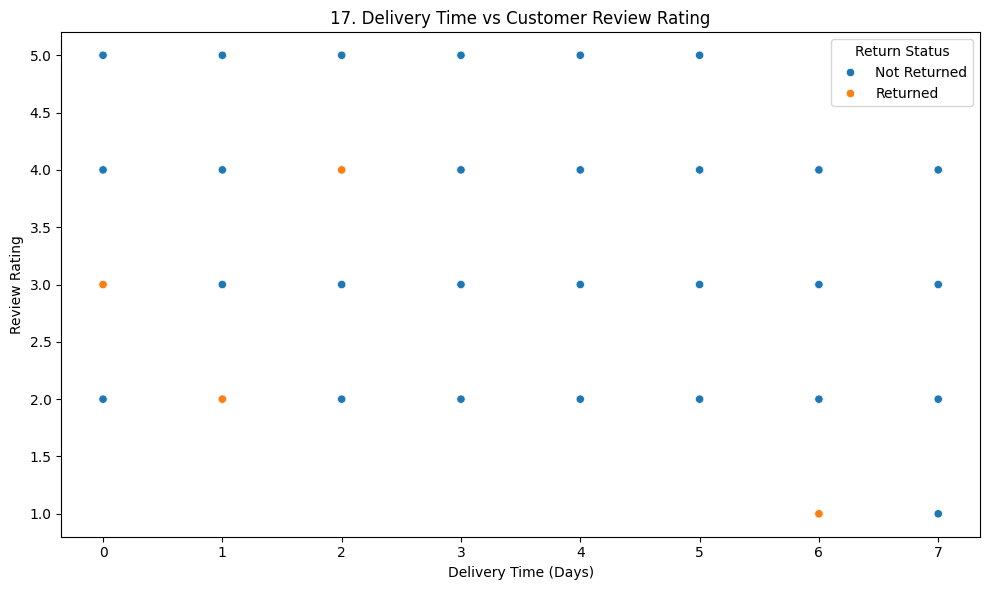

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Delivery Time (Days)', y='Review Rating', hue='Return Status')
plt.title(f'{plot_no}. Delivery Time vs Customer Review Rating')
show_fig()
plot_no += 1

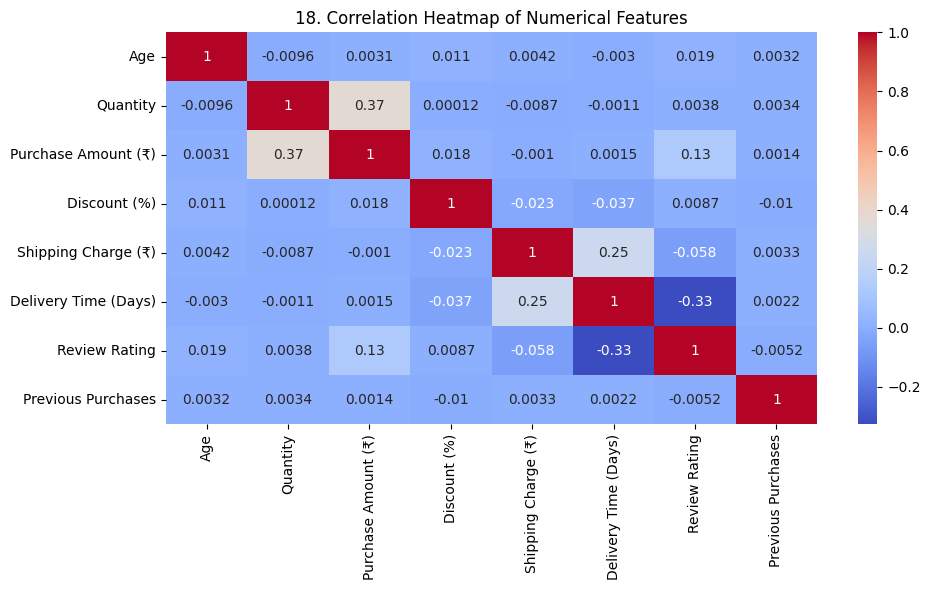

In [30]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of dataset

In [31]:
data = df.copy()

## Remove unnecessary columns

In [32]:
drop_cols = ["Transaction ID", "Customer ID", "Purchase Date"]
for col in drop_cols:
    if col in data.columns:
        data.drop(columns=col, inplace=True)

## Select target column

In [33]:
target = "Subscription Status"

## Convert target into binary values

In [34]:
data[target] = data[target].map({"Yes": 1, "No": 0})

## Remove missing target values

In [35]:
data = data.dropna(subset=[target])

## Separate features and target

In [36]:
X = data.drop(columns=[target])
y = data[target]

## Identify numerical and categorical columns

In [37]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

## Create preprocessing pipeline

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            cat_cols
        )
    ]
)

## Split dataset

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Create machine learning pipeline

In [40]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=8,
        max_iter=400,
        min_samples_leaf=15,
        random_state=42
    ))
])

## Train model

In [41]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Quantity',
                                                   'Purchase Amount (₹)',
                                                   'Discount (%)',
                                                   'Shipping Charge (₹)',
                                                   'Delivery Time (Days)',
                                                   'Review Rating',
                                                   'Previous Purchases']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Location',
                                                   'Online/Offline',
                                                   'Online Store', 'Category',
                                                   'Item Purchased', 'Brand',
                                                   'Color', 'Size',
                                                   'Festival/Sale',
                                                   'Delivery Speed',
                                                   'Payment Method',
                                                   'Return Status',
                                                   'Frequency of '
                                                   'Purchases'])])),
                ('classifier',
                 HistGradientBoostingClassifier(learning_rate=0.05, max_depth=8,
                                                max_iter=400,
                                                min_samples_leaf=15,
                                                random_state=42))])

## Predict test data

In [42]:
y_pred = model.predict(X_test)

## Calculate accuracy

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {round(accuracy * 100)}%")

Accuracy Score: 75%


## Display confusion matrix

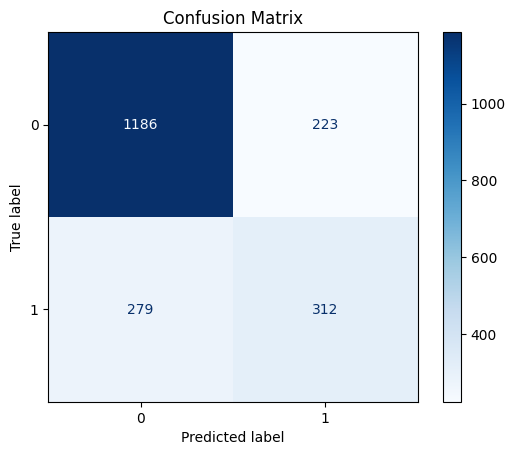

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()